# Inference Guide for DesigNet


You will go through the complete pipeline:

1. Load a pretrained checkpoint and model configuration.
2. Build one font sample from SVG glyph files.
3. Reconstruct a full font (self + cross glyph predictions).
4. Visualize interpolation between two fonts in latent space.
5. Apply self-refinement (alignment/continuity) and compare outputs.
6. Save generated glyphs back to SVG files for downstream inspection or export.

The notebook operates on real data from `demo_data/` and leverages the inference interface defined in [`src/genai/scripts/inference.py`](../scripts/inference.py), which provides all the required methods for running inference.

---
## Environment, Paths, and Expected Layout

Before running inference, verify the repository layout expected by this notebook:

```text
DesigNet/
  demo_data/
    SampleFont/
      *.svg
    SampleFontBold/
      *.svg
  demo_outputs/
    (created automatically)
```

Path conventions used below:

- `PROJECT_ROOT` is set to the `DesigNet/` folder.
- `font_dir` points to one folder containing glyph SVGs for a single font.

Checkpoint availability note:

- This notebook expects a pretrained file named `DesigNet.ckpt`.
- If the file is not present locally, download the latest release checkpoint and place it at `checkpoints/DesigNet.ckpt` (or update `checkpoint_path` accordingly).

The import cell also appends `PROJECT_ROOT` to `sys.path` so local modules under `src/` can be imported without installing a separate package.

In [10]:
!pip install -e .

Obtaining file:///home/iago/workspace/DesigNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for designet (pyproject.toml) ... done
  Created wheel for designet: filename=designet-1.0-0.editable-py3-none-any.whl size=4146 sha256=fb2c7a562195d5724da543db28a70bd5294dc0140dd5ee6b3135720e23271bf2
  Stored in directory: /tmp/pip-ephem-wheel-cache-dm7ahuuq/wheels/d1/15/68/a86d3298ad12b6a0529abfead1de815251230e72e2aa331a95
Successfully built designet
  Attempting uninstall: designet
    Found existing installation: designet 1.0
    Uninstalling designet-1.0:
      Successfully uninstalled designet-1.0

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
from pathlib import Path
import sys
import torch
from matplotlib import pyplot as plt

from designet.tools import (
    plot_word_from_glyph_set,
    svg_from_cmd_args,
    reconstruct_font,
    interpolate_two_fonts_linear,
    save_reconstructed_font_svgs,
    load_designet_model,
    refine_output_with_soft_refinement,
)
from designet.font_loader import FontLoader, FontLoaderConfig

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

PROJECT_ROOT = Path(".").resolve()
font_dir = PROJECT_ROOT / "demo_data" / "SampleFont"

---
## Loading the Pretrained Checkpoint

In [13]:
model, cfg, ckpt = load_designet_model(device=device, strict=False)

print("Loaded model.")
print("num_encoding_glyphs:", cfg["num_encoding_glyphs"])
print("num_decoding_glyphs:", cfg["num_decoding_glyphs"])

Download complete.
[load warning] Unexpected keys: ['loss_fn.cmd_args_mask']
Loaded model.
num_encoding_glyphs: 8
num_decoding_glyphs: 44


---
## Initializing the Font Loader

The loader section converts one font folder of SVG files into model-ready tensors.

- `FontLoaderConfig` must match the checkpoint configuration (`max_num_groups`, `max_seq_len`, argument format).
- `encoding_letters` and `decoding_letters` come from checkpoint config.
- Normalization/centering are enabled so input geometry is in the expected coordinate regime.

In [14]:
available = sorted([p.stem for p in font_dir.glob("*.svg")])

encoding_letters = list(cfg["encoding_glyphs"])
decoding_letters = list(cfg["decoding_glyphs"])

loader_cfg = FontLoaderConfig(
    max_num_groups=cfg["max_num_groups"],
    max_seq_len=cfg["max_seq_len"],
    encoding_letters=encoding_letters,
    decoding_letters=decoding_letters,
    normalize=True,
    center=True,
    compute_continuity=False,
    compute_line_alignment=False,
)

loader = FontLoader(font_dir, loader_cfg)

print("Loaded glyph set size:", len(available))
print("Encoding glyphs:", encoding_letters)
print("Decoding glyphs:", decoding_letters)

Loaded glyph set size: 62
Encoding glyphs: ['H', 'a', 'm', 'b', 'u', 'r', 'g', 'e']
Decoding glyphs: ['A', 'B', 'C', 'c', 'D', 'd', 'E', 'F', 'f', 'G', 'h', 'I', 'i', 'J', 'j', 'K', 'k', 'L', 'l', 'M', 'N', 'n', 'O', 'o', 'P', 'p', 'Q', 'q', 'R', 'S', 's', 'T', 't', 'U', 'V', 'v', 'W', 'w', 'X', 'x', 'Y', 'y', 'Z', 'z']


---
## Font Reconstruction (Single-Font Inference)

This section runs full-font reconstruction from one loaded sample.

Conceptually, the model does the following:

1. Encodes reference glyphs (encoding subset) into latent conditioning features.
2. Combines latent conditioning with glyph identity embeddings.
3. Decodes command and argument logits for both self and cross selections.
4. Applies greedy sampling and validity/closure rules to obtain final SVG command streams.Ç

Word used: handgloves


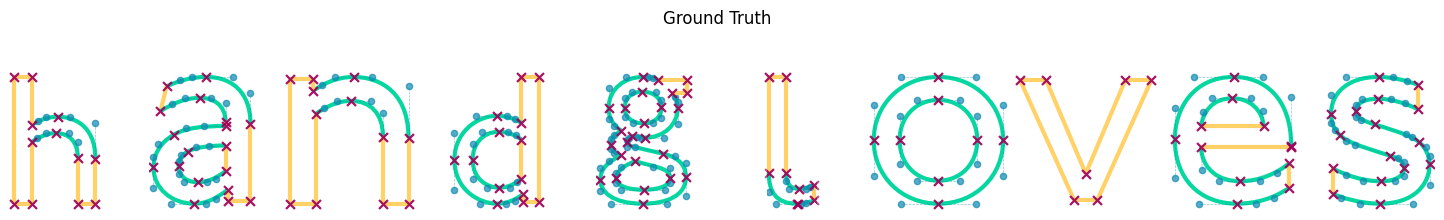

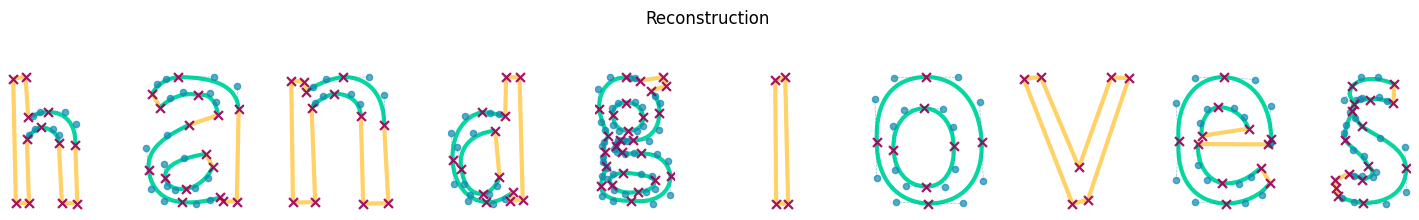

In [15]:
sample = loader.get()

recon = reconstruct_font(
    model=model,
    font_sample=sample,
    device=device,
    close_paths=True,
)

glyph_names = sample.get("glyph_names") or []

word = "handgloves"

gt_cmds = sample["input_commands"][0]
gt_args = sample["input_args"][0]
pr_cmds = recon["commands"][0]
pr_args = recon["args"][0]

_ = plot_word_from_glyph_set(
    glyph_commands=gt_cmds,
    glyph_args=gt_args,
    word=word,
    glyph_names=glyph_names,
    show_handles=True,
    panel_size=(1.5, 2.2),
    title="Ground Truth",
)

_ = plot_word_from_glyph_set(
    glyph_commands=pr_cmds,
    glyph_args=pr_args,
    word=word,
    glyph_names=glyph_names,
    show_handles=True,
    panel_size=(1.5, 2.2),
    title="Reconstruction",
)

print("Word used:", word)
plt.show()

---
## Exporting Reconstructed SVGs

The export utility writes generated glyphs as individual SVG files for external inspection.

In [16]:
saved_paths = save_reconstructed_font_svgs(
    reconstruction=recon,
    output_dir=PROJECT_ROOT / "demo_outputs" / "genai_reconstruction",
    glyph_names=sample.get("glyph_names"),
)

---
## Interpolation Between Two Fonts (Linear in Latent Conditioning)

This section blends two fonts, `A` and `B`, using linear interpolation in conditioning space.

For interpolation coefficient $\alpha \in [0,1]$ and conditioning tensors $c_A, c_B$ (and, when hierarchical, group-conditioning tensors $g_A, g_B$):

$$
c_{\alpha} = (1-\alpha)c_A + \alpha c_B
$$

$$
g_{\alpha} = (1-\alpha)g_A + \alpha g_B
$$

Interpretation:

- $\alpha=0$ reproduces style from font $A$
- $\alpha=1$ reproduces style from font $B$
- intermediate values smoothly traverse style space

In this exmaple we interpolate between two different styles from the same font family, from Regular to Bold.

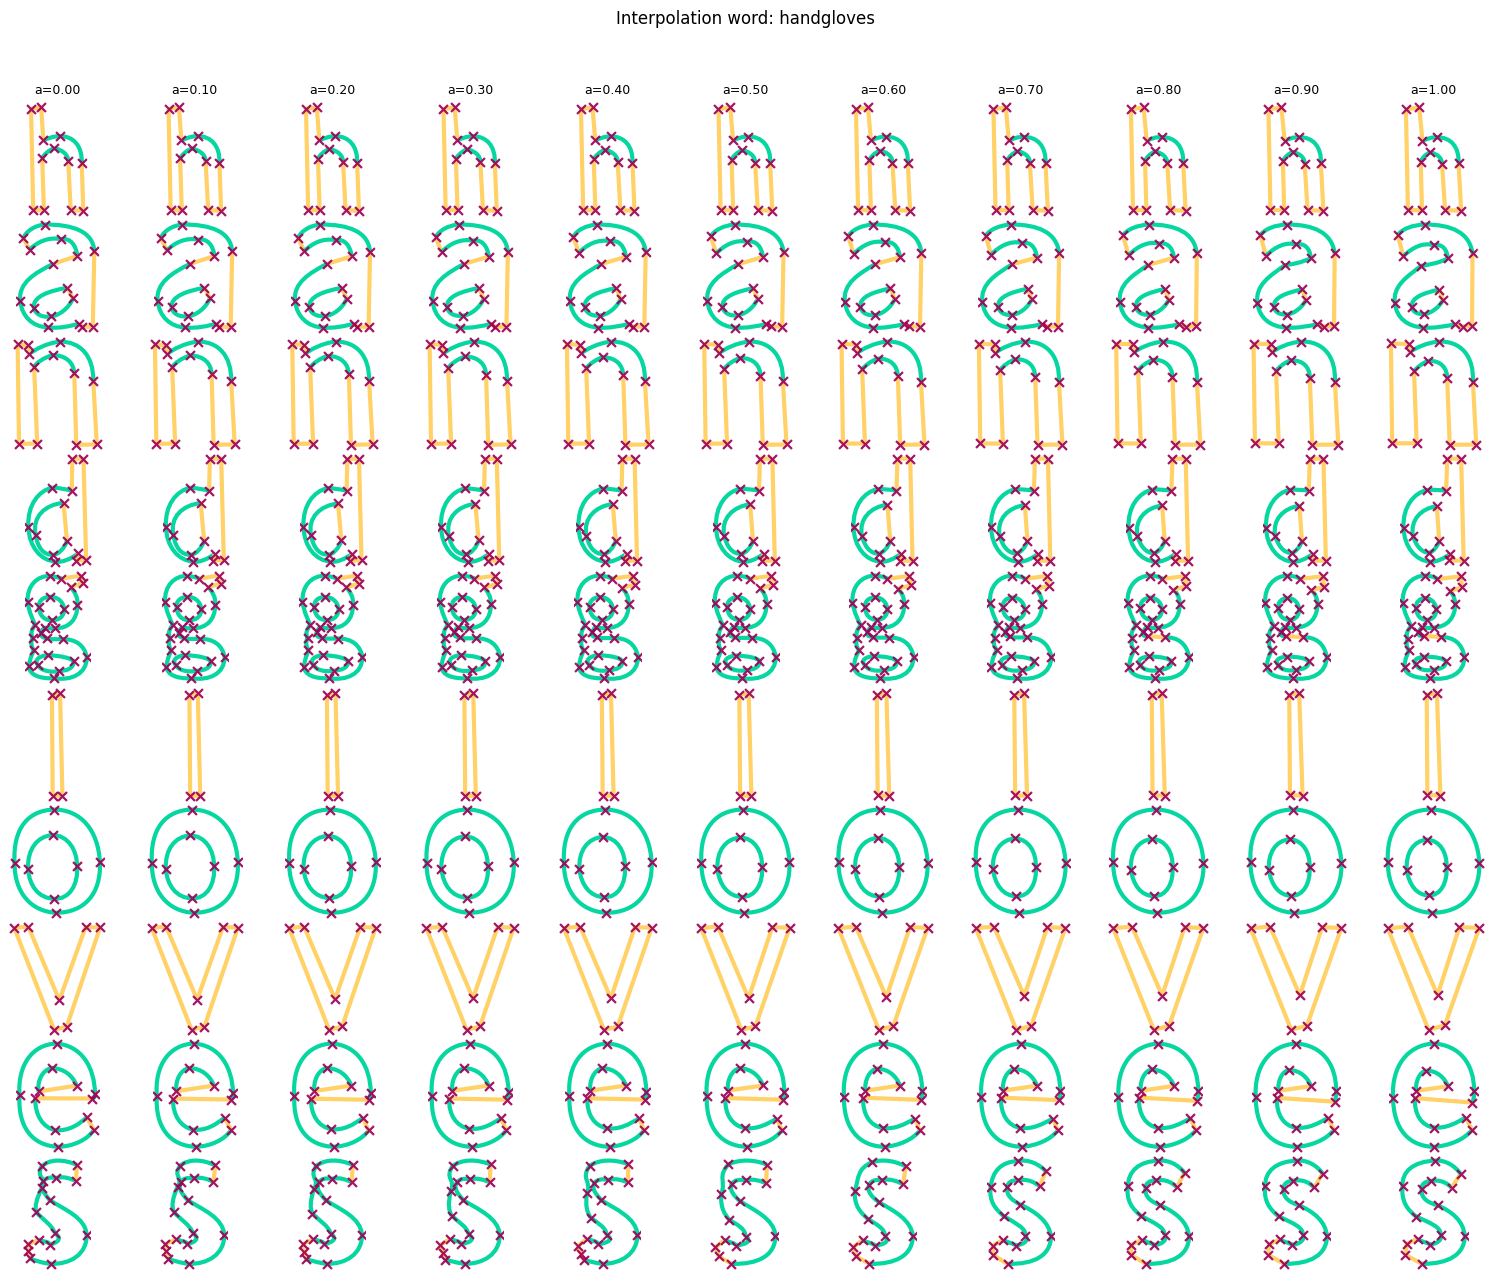

In [17]:
# Word-level interpolation: rows are glyphs, columns are interpolation steps
font_dir_a = PROJECT_ROOT / "demo_data" / "SampleFont"
font_dir_b = PROJECT_ROOT / "demo_data" / "SampleFontBold"

loader_a = FontLoader(font_dir_a, loader_cfg)
loader_b = FontLoader(font_dir_b, loader_cfg)
sample_a = loader_a.get()
sample_b = loader_b.get()

glyph_names = sample_a.get("glyph_names") or []

word = "handgloves"

alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
interp = interpolate_two_fonts_linear(
    model=model,
    font_sample_a=sample_a,
    font_sample_b=sample_b,
    alphas=alphas,
    device=device,
    close_paths=True,
)

name_to_idx = {g: i for i, g in enumerate(glyph_names)}
indices = [name_to_idx[ch] for ch in word]

n_rows = len(indices)
n_cols = len(alphas)
fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(1.4 * n_cols, 1.3 * n_rows),
    squeeze=False,
)

for r, idx in enumerate(indices):
    for c, (a, rec) in enumerate(zip(alphas, interp["interpolations"])):
        svg = svg_from_cmd_args(
            rec["commands"][0, idx],
            rec["args"][0, idx],
        )
        ax = axs[r][c]
        svg.draw_matplotlib(ax, show_handles=False)
        ax.axis("off")
        if r == 0:
            ax.set_title(f"a={a:.2f}", fontsize=9)
    axs[r][0].set_ylabel(word[r], rotation=0, labelpad=10, va="center", fontsize=9)

fig.suptitle(f"Interpolation word: {word}")
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
fig.subplots_adjust(wspace=0.03, hspace=0.03)
plt.show()

---
## Self-Refinement (Alignment and Continuity)

After reconstruction, self-refinement can improve geometric consistency of path arguments.

The refinement pass uses predicted auxiliary logits:

- alignment logits: improve local geometric alignment
- continuity logits: improve path continuity transitions

Confidence gating is applied with thresholds (`align_min_conf`, `cont_min_conf`):

- if predicted class confidence is above threshold, use the predicted class
- otherwise, fallback to a no-op class to avoid low-confidence overcorrection

Word used: selfrefinement


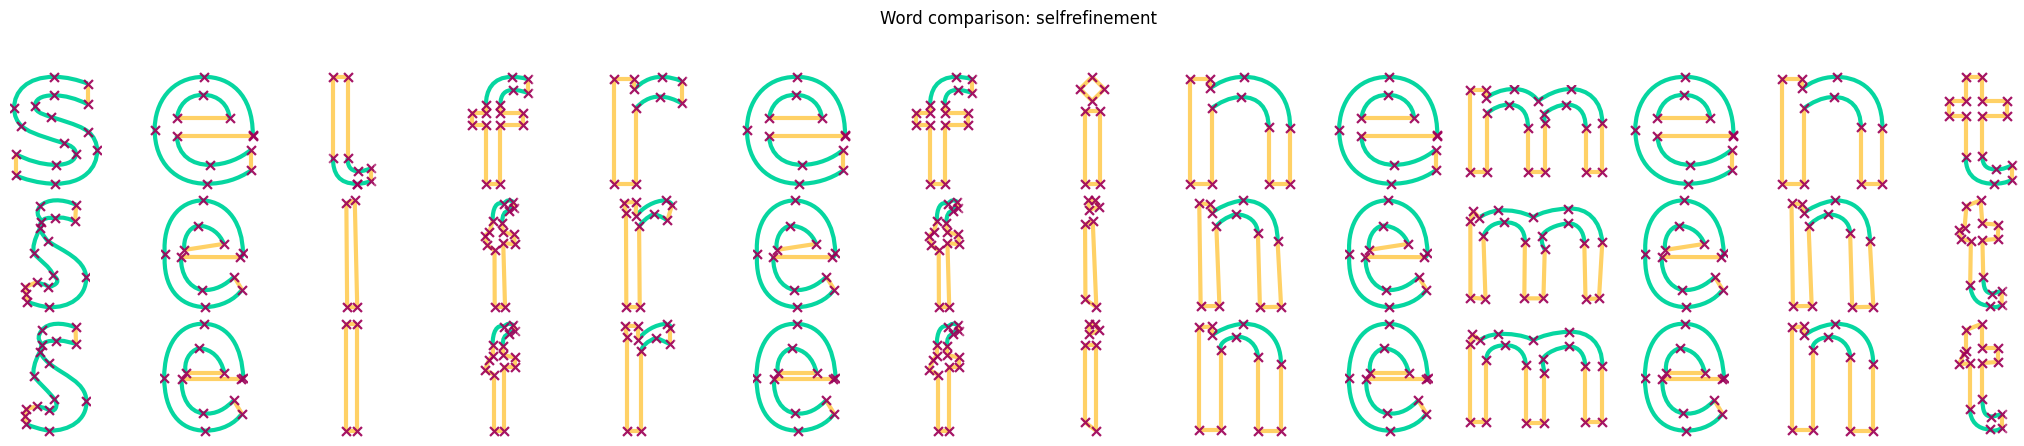

In [18]:
# Word-level 3-row comparison: GT, Pre-refinement, Post-refinement
glyph_names = sample.get("glyph_names") or []
glyph_set = set(glyph_names)

word = "selfrefinement"
if not all(ch in glyph_set for ch in word):
    word = "".join(glyph_names[: min(6, len(glyph_names))])

sample_dev = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in sample.items()}
input_commands = sample_dev["input_commands"]
input_args = sample_dev["input_args"]
bsz = input_commands.shape[0]

sel_self_eff = torch.arange(model.num_encoding_letters, device=input_commands.device).unsqueeze(0).expand(bsz, -1)
sel_cross_eff = torch.arange(model.num_decoding_letters, device=input_commands.device).unsqueeze(0).expand(bsz, -1)

with torch.no_grad():
    out_pre = model(
        input_commands=input_commands,
        input_args=input_args,
        return_tgt=False,
        sel_self=sel_self_eff,
        sel_cross=sel_cross_eff,
    )

    out_post = refine_output_with_soft_refinement(
        out_pre,
        align_min_conf=0.7,
        cont_min_conf=0.7,
    )

    cmd_cross_pre, arg_cross_pre, cmd_self_pre, arg_self_pre = model.greedy_sample(
        pred=out_pre,
        close_paths=True,
        sel_self=sel_self_eff,
        sel_cross=sel_cross_eff,
    )

    cmd_cross_post, arg_cross_post, cmd_self_post, arg_self_post = model.greedy_sample(
        pred=out_post,
        close_paths=True,
        sel_self=sel_self_eff,
        sel_cross=sel_cross_eff,
    )

k_self = sel_self_eff.shape[1]
k_cross = sel_cross_eff.shape[1]

cmd_self_pre = cmd_self_pre.unflatten(0, (bsz, k_self))
arg_self_pre = arg_self_pre.unflatten(0, (bsz, k_self))
cmd_cross_pre = cmd_cross_pre.unflatten(0, (bsz, k_cross))
arg_cross_pre = arg_cross_pre.unflatten(0, (bsz, k_cross))

cmd_self_post = cmd_self_post.unflatten(0, (bsz, k_self))
arg_self_post = arg_self_post.unflatten(0, (bsz, k_self))
cmd_cross_post = cmd_cross_post.unflatten(0, (bsz, k_cross))
arg_cross_post = arg_cross_post.unflatten(0, (bsz, k_cross))

n_total = model.num_encoding_letters + model.num_decoding_letters

commands_pre = cmd_self_pre.new_full((bsz, n_total, cmd_self_pre.shape[2], cmd_self_pre.shape[3]), 3)
args_pre = arg_self_pre.new_full(
    (bsz, n_total, arg_self_pre.shape[2], arg_self_pre.shape[3], arg_self_pre.shape[4]), -1
)
commands_post = cmd_self_post.new_full((bsz, n_total, cmd_self_post.shape[2], cmd_self_post.shape[3]), 3)
args_post = arg_self_post.new_full(
    (bsz, n_total, arg_self_post.shape[2], arg_self_post.shape[3], arg_self_post.shape[4]), -1
)

for b in range(bsz):
    commands_pre[b, sel_self_eff[b]] = cmd_self_pre[b]
    args_pre[b, sel_self_eff[b]] = arg_self_pre[b]
    cross_pos = sel_cross_eff[b] + model.num_encoding_letters
    commands_pre[b, cross_pos] = cmd_cross_pre[b]
    args_pre[b, cross_pos] = arg_cross_pre[b]

    commands_post[b, sel_self_eff[b]] = cmd_self_post[b]
    args_post[b, sel_self_eff[b]] = arg_self_post[b]
    commands_post[b, cross_pos] = cmd_cross_post[b]
    args_post[b, cross_pos] = arg_cross_post[b]

name_to_idx = {g: i for i, g in enumerate(glyph_names)}
indices = [name_to_idx[ch] for ch in word]

gt_cmds = sample["input_commands"][0]
gt_args = sample["input_args"][0]
pre_cmds = commands_pre[0].detach().cpu()
pre_args = args_pre[0].detach().cpu()
post_cmds = commands_post[0].detach().cpu()
post_args = args_post[0].detach().cpu()

n_rows, n_cols = 3, len(indices)
fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(1.5 * n_cols, 1.5 * n_rows),
    squeeze=False,
)

row_specs = [
    ("GT", gt_cmds, gt_args),
    ("Pre-refinement", pre_cmds, pre_args),
    ("Post-refinement", post_cmds, post_args),
]

for r, (row_name, row_cmds, row_args) in enumerate(row_specs):
    for c, idx in enumerate(indices):
        svg = svg_from_cmd_args(
            row_cmds[idx],
            row_args[idx],
        )
        ax = axs[r][c]
        svg.draw_matplotlib(ax, show_handles=False)
        ax.axis("off")
    axs[r][0].set_ylabel(row_name, rotation=0, labelpad=18, va="center")

fig.suptitle(f"Word comparison: {word}")
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
fig.subplots_adjust(wspace=0.02, hspace=0.05)
print("Word used:", word)
plt.show()

In [19]:
recon_ref_for_save = {
    "commands": commands_post,
    "args": args_post,
}

saved_paths = save_reconstructed_font_svgs(
    reconstruction=recon_ref_for_save,
    output_dir=PROJECT_ROOT / "demo_outputs" / "genai_reconstruction_refined",
    glyph_names=sample.get("glyph_names"),
)